# 02: Data Compilation

Take our disjoint datasets and compile them into a single dataset.

In [2]:
import os
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

in_dirs = ['data_intermediate/other', 'data_intermediate/unknown']
out_dir = 'data'
files = ['clinical_covariates.csv', 'survival.csv', 'transcriptomic_features.csv']

for file in files:
    in_dfs = [pd.read_csv(os.path.join(in_dir, file)) for in_dir in in_dirs]
    out_df = pd.concat(in_dfs)
    out_df.drop_duplicates(inplace=True)
    out_df.to_csv(os.path.join(out_dir, file), index=False)

In [3]:
# Create metagene expression for the random split

my_expression_df = pd.read_csv(os.path.join(out_dir, 'transcriptomic_features.csv'))
my_splits = pd.read_csv('data/splits.csv')
train_ids = my_splits[my_splits['Set'] == 'Train']['sample_id']
train_expression_df = my_expression_df[my_expression_df['sample_id'].isin(train_ids)]
train_expression_df.drop(columns=['sample_id'], inplace=True)
pca = PCA(n_components=50)
pca.fit(train_expression_df)
metagene_expression = pca.transform(my_expression_df.drop(columns=['sample_id']))
metagene_expression_df = pd.DataFrame(metagene_expression, columns=[f'PC{i}' for i in range(50)])
metagene_expression_df['sample_id'] = my_expression_df['sample_id']
metagene_expression_df.to_csv(os.path.join(out_dir, 'metagene_expression.csv'), index=False)

/var/folders/_6/468mk1cx3cb080z2r5gq0k_r0000gn/T/ipykernel_4686/3400547309.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_expression_df.drop(columns=['sample_id'], inplace=True)


Total captured variance 0.7976975569664306


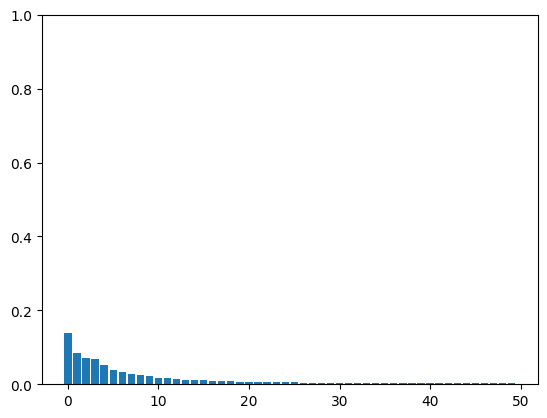

In [5]:
print('Total captured variance', sum(pca.explained_variance_ratio_))
plt.bar(list(range(50)), pca.explained_variance_ratio_)
plt.ylim(0, 1)
plt.show()